In [1]:
from pathlib import Path
import zipfile

data_path = Path("data/")
data_path.mkdir(exist_ok=True)

voc2007_zip_path = Path("VOC2007.zip")
voc2012_zip_path = Path("VOC2012.zip")

if not voc2007_zip_path.exists() or not voc2012_zip_path.exists():
    raise RuntimeError("Dataset not found.")

print("Extracting 2007 dataset ...")

with zipfile.ZipFile(voc2007_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

print(f"Extracting 2012 dataset ...")
with zipfile.ZipFile(voc2012_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

Extracting 2007 dataset ...
Extracting 2012 dataset ...


In [2]:
voc2007_path = data_path / "VOC2007"
voc2012_path = data_path / "VOC2012"

voc2007_img_path = voc2007_path / "JPEGImages"
voc2012_img_path = voc2012_path / "JPEGImages"

In [3]:
# class to idx in VOC dataset
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable",
    "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]

cls_to_idx = {cls_name: idx for idx, cls_name in enumerate(VOC_CLASSES)}
cls_to_idx

{'aeroplane': 0,
 'bicycle': 1,
 'bird': 2,
 'boat': 3,
 'bottle': 4,
 'bus': 5,
 'car': 6,
 'cat': 7,
 'chair': 8,
 'cow': 9,
 'diningtable': 10,
 'dog': 11,
 'horse': 12,
 'motorbike': 13,
 'person': 14,
 'pottedplant': 15,
 'sheep': 16,
 'sofa': 17,
 'train': 18,
 'tvmonitor': 19}

In [9]:
voc2007_trainval = voc2007_path / "ImageSets" / "Main" / "trainval.txt"
voc2012_trainval = voc2012_path / "ImageSets" / "Main" / "trainval.txt"

with open(voc2007_trainval, "r") as f:
    voc2007_img_paths_train = [voc2007_img_path / (line.strip() + ".jpg") for line in f.readlines()]
with open(voc2012_trainval, "r") as f:
    voc2012_img_paths_train = [voc2012_img_path / ((line.strip()).split(" ")[0] + ".jpg") for line in f.readlines()]

voc2007_img_paths_train, voc2012_img_paths_train

([PosixPath('data/VOC2007/JPEGImages/000005.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000007.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000009.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000012.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000016.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000017.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000019.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000020.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000021.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000023.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000024.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000026.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000030.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000032.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000033.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000034.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000035.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000036.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000039.jpg'),
  PosixPath('data/VOC2007/JPEGI

In [10]:
voc2007_test = voc2007_path / "ImageSets" / "Main" / "test.txt"
voc2012_test = voc2012_path / "ImageSets" / "Main" / "test.txt"

with open(voc2007_test, "r") as f:
    voc2007_img_paths_test = [voc2007_img_path / (line.strip() + ".jpg") for line in f.readlines()]
with open(voc2012_test, "r") as f:
    voc2012_img_paths_test = [voc2012_img_path / ((line.strip()).split(" ")[0] + ".jpg") for line in f.readlines()]

voc2007_img_paths_test, voc2012_img_paths_test

([PosixPath('data/VOC2007/JPEGImages/000001.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000002.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000003.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000004.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000006.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000008.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000010.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000011.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000013.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000014.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000015.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000018.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000022.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000025.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000027.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000028.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000029.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000031.jpg'),
  PosixPath('data/VOC2007/JPEGImages/000037.jpg'),
  PosixPath('data/VOC2007/JPEGI

In [ ]:
import xml.etree.ElementTree as ET

def voc_to_dict(annotation_path):
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    img_width = float(root.find("size").find("width").text)
    img_height = float(root.find("size").find("height").text)

    annotation_data = {
        "filename" : root.find("filename").text,
        "size" : {
            "width" : img_width,
            "height" : img_height,
            "depth" : int(root.find("size").find("depth").text)
        },
        "objects" : []
    }

    for obj in root.findall("object"):

        obj_dict = {
            "name" : obj.find("name").text,
            "class_idx" : cls_to_idx[obj.find("name").text],
            "bndbox" : {
                "x_min" : float(obj.find("bndbox").find("xmin").text)/img_width,
                "y_min" : float(obj.find("bndbox").find("ymin").text)/img_height,
                "x_max" : float(obj.find("bndbox").find("xmax").text)/img_width,
                "y_max" : float(obj.find("bndbox").find("ymax").text)/img_height
            }
        }

        annotation_data["objects"].append(obj_dict)

    return annotation_data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_image_with_annotations(img_array, annotation_dict, img_width=None, img_height=None):
    fig, ax = plt.subplots(1)
    ax.imshow(img_array)

    if img_width is None:
        img_width = annotation_dict["size"]["width"]
    if img_height is None:
        img_height = annotation_dict["size"]["height"]

    for obj in annotation_dict["objects"]:
        x_min = obj["bndbox"]["x_min"]*img_width
        y_min = obj["bndbox"]["y_min"]*img_height
        x_max = obj["bndbox"]["x_max"]*img_width
        y_max = obj["bndbox"]["y_max"]*img_height

        width = x_max - x_min
        height = y_max - y_min

        rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        ax.text(x_min, y_min - 5, obj["name"], color='r', fontsize=12, weight='bold')

    plt.show()

In [ ]:
import random
from PIL import Image

idx = random.randint(0, len(voc2007_img_paths_train)-1)
random_img_path = voc2007_img_paths_train[idx]
random_annotation_path = voc2007_path / "Annotations" / (random_img_path.stem + ".xml")

print(random_img_path)
print(random_annotation_path)


annotation_dict = voc_to_dict(random_annotation_path)

img = Image.open(random_img_path)

data/VOC2007/JPEGImages/004133.jpg
data/VOC2007/Annotations/004133.xml


(334, 500, 3)


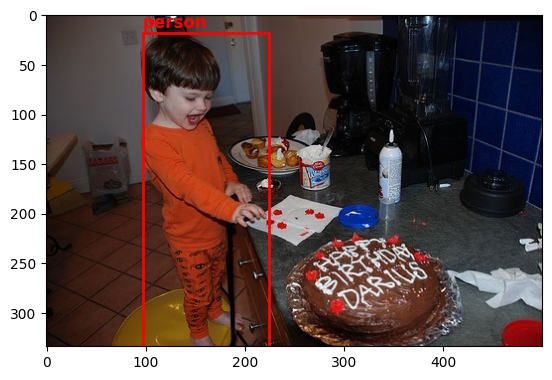

In [ ]:
img_array = np.array(img)
print(img_array.shape)

plot_image_with_annotations(img_array, annotation_dict)

In [ ]:
from requests.packages import target
from torchvision.transforms import functional as TF
import copy

# Here we could have used transforms.Compose(lambda img : resize_shorter_side(img), ToTensor()) without returning the target
# But as a practice, we will create custom transform classes to handle both the image and its corresponding annotation dictionary.

# Create a custom transform class to convert PIL images to PyTorch tensors and apply the resize transformation 
class ToTensorTransform:
    def __call__(self, img, target):
        img = TF.to_tensor(img)
        return img, target

# Create a custom transform class to resize the shorter side of the image using resize_shorter_side function and update the annotation dictionary accordingly
class ResizeTransform:
    def __init__(self, short_side=600, max_side=1000):
        self.short_side = short_side
        self.max_side = max_side

    def __call__(self, img, target):
        return self.resize_shorter_side(img, target)

    # resize fn to resize the shorter side of the image to a specified size while maintaining the aspect ratio, and also update the annotation dictionary with the new dimensions of the image.
    def resize_shorter_side(self, img, target):
        annotation_dict = copy.deepcopy(target)
        h, w = img.size

        scale = self.short_side / min(w, h)
        if scale * max(w, h) > self.max_side:
            scale = self.max_side / max(w, h)

        new_w = int(w * scale)
        new_h = int(h * scale)

        annotation_dict["size"]["new_width"] = new_w
        annotation_dict["size"]["new_height"] = new_h

        return TF.resize(img, (new_h, new_w)), annotation_dict

# Create a composed transform class to apply multiple transformations sequentially
class ComposedTransform:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, target):
        for transform in self.transforms:
            img, target = transform(img, target)
        return img, target


transform = ComposedTransform([
    ResizeTransform(short_side=600, max_side=1000),
    ToTensorTransform()
])

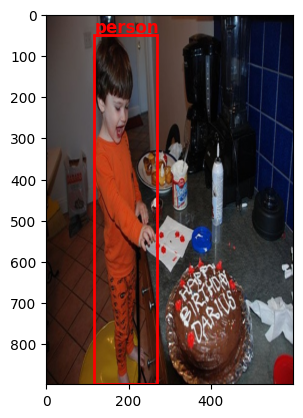

(torch.Size([3, 898, 600]), 898, 600)

In [ ]:
transformed_img, transformed_annotation_dict = transform(img, annotation_dict)
plot_image_with_annotations(transformed_img.permute(1, 2, 0).numpy(), transformed_annotation_dict, img_width=transformed_annotation_dict["size"]["new_width"], img_height=transformed_annotation_dict["size"]["new_height"])
transformed_img.shape, transformed_annotation_dict["size"]["new_height"], transformed_annotation_dict["size"]["new_width"]

In [ ]:
from torch.utils.data import Dataset

class VOCDataset(Dataset):
    def __init__(self, img_paths_list, transform=None):
        self.img_paths_list = img_paths_list
        self.transform = transform

    def __len__(self):
        return len(self.img_paths_list)
    
    def __getitem__(self, idx):
        img_path = self.img_paths_list[idx]
        annotation_path = img_path.parents[1] / "Annotations" / (img_path.stem + ".xml")

        img = Image.open(img_path)
        annotation_dict = voc_to_dict(annotation_path)

        if self.transform:
            img, annotation_dict = self.transform(img, target=annotation_dict)
        
        return img, annotation_dict

In [ ]:
voc2007_dataset_train = VOCDataset(voc2007_img_paths_train, transform=transform)
print(f"Length of VOC2007 dataset: {len(voc2007_dataset_train)}")
print(f"Sample from VOC2007 dataset: {voc2007_dataset_train[1][0].shape, voc2007_dataset_train[1][1]}")

Length of VOC2007 dataset: 646
Sample from VOC2007 dataset: (torch.Size([3, 900, 600]), {'filename': '000007.jpg', 'size': {'width': 500.0, 'height': 333.0, 'depth': 3, 'new_width': 600, 'new_height': 900}, 'objects': [{'name': 'car', 'class_idx': 6, 'bndbox': {'x_min': 0.282, 'y_min': 0.15015015015015015, 'x_max': 1.0, 'y_max': 0.990990990990991}}]})


In [ ]:
import torch
import torch.nn as nn

def collate_fn(batch):
    imgs, annotations = zip(*batch)

    max_height = max(img.shape[1] for img in imgs)
    max_width = max(img.shape[2] for img in imgs)

    padded_imgs = []
    img_sizes_before_pad = []
    gt_boxes = []
    gt_labels = []

    for img, annotation in zip(imgs, annotations):
        img_height, img_width = img.shape[1], img.shape[2]
        pad_height = max_height - img_height
        pad_width = max_width - img_width

        img_sizes_before_pad.append((img_height, img_width))  # Store original height and width

        padded_img = nn.functional.pad(img, (0, pad_width, 0, pad_height), mode='constant', value=0)
        padded_imgs.append(padded_img)

        boxes = torch.tensor([
            [obj["bndbox"]["x_min"]* img_width, 
             obj["bndbox"]["y_min"]* img_height, 
             obj["bndbox"]["x_max"]* img_width, 
             obj["bndbox"]["y_max"]* img_height]
             for obj in annotation["objects"]], dtype=torch.float32)
        
        labels = torch.tensor([obj["class_idx"] for obj in annotation["objects"]], dtype=torch.int64)

        gt_boxes.append(boxes)
        gt_labels.append(labels)

    return torch.stack(padded_imgs, dim=0), gt_boxes, gt_labels, img_sizes_before_pad


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(voc2007_dataset_train, batch_size=32, shuffle=True, collate_fn=collate_fn)

In [ ]:
img, gt_boxes, gt_labels, pre_pad_img_sizes = next(iter(train_loader))
img.shape, gt_boxes, gt_labels, pre_pad_img_sizes

(torch.Size([32, 3, 923, 1000]),
 [tensor([[  1.2000,  97.2973, 600.0000, 786.4865]]),
  tensor([[394.8000, 213.3333, 454.8000, 341.3333]]),
  tensor([[303.6000, 296.5333, 482.4000, 588.8000]]),
  tensor([[ 38.4000,   2.1333, 564.0000, 678.4000]]),
  tensor([[ 79.3422, 344.4000, 398.8556, 583.2000],
          [388.1337, 434.4000, 647.6042, 549.6000],
          [403.1444,   2.4000, 701.2139, 472.8000]]),
  tensor([[ 18.0000, 217.2000,  90.0000, 313.2000],
          [ 88.8000, 208.8000, 132.0000, 298.8000],
          [363.6000, 242.4000, 464.4000, 380.4000],
          [561.6000, 225.6000, 600.0000, 368.4000],
          [480.0000, 225.6000, 558.0000, 355.2000],
          [409.2000, 214.8000, 478.8000, 342.0000],
          [454.8000, 164.4000, 561.6000, 355.2000],
          [409.2000, 175.2000, 476.4000, 337.2000],
          [106.8000,  22.8000, 387.6000, 592.8000],
          [235.2000,  18.0000, 405.6000, 577.2000]]),
  tensor([[328.8000,  27.7333, 494.4000, 797.8666],
          [  6.0000

In [ ]:
gt_labels

[tensor([0]),
 tensor([19]),
 tensor([14]),
 tensor([9]),
 tensor([15, 15, 15]),
 tensor([ 8,  8,  8,  8,  8,  8, 14, 14, 14, 14]),
 tensor([14, 13]),
 tensor([19, 14,  4]),
 tensor([14,  8]),
 tensor([14,  1]),
 tensor([12]),
 tensor([9]),
 tensor([14,  8]),
 tensor([9]),
 tensor([2, 2, 2, 2]),
 tensor([16]),
 tensor([17, 14]),
 tensor([11, 17, 14]),
 tensor([ 8,  8,  8,  8,  8,  8,  8,  8,  8, 14]),
 tensor([14,  6,  6,  6,  6,  6]),
 tensor([ 1, 14, 14]),
 tensor([17, 14]),
 tensor([7]),
 tensor([ 3, 14]),
 tensor([17, 14]),
 tensor([6, 6, 6, 6, 6, 6]),
 tensor([3]),
 tensor([17, 14]),
 tensor([0, 0, 0, 0, 0]),
 tensor([13, 14]),
 tensor([6]),
 tensor([ 1, 14,  6,  6])]

In [ ]:
import matplotlib.pyplot as plt
import random
from src.dataset import VOC_CLASSES

def display_random_batch_images(batch_images, batch_boxes, batch_labels=None, num_images=4):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        idx = random.randint(0, len(batch_images) - 1)
        img = batch_images[idx].permute(1, 2, 0).cpu().numpy()  # Convert to HWC format and move to CPU
        boxes = batch_boxes[idx].cpu().numpy()

        axes[i].imshow(img)
        axes[i].set_title(f"Image {idx}")
        axes[i].axis('off')

        for j, box in enumerate(boxes):
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2)
            axes[i].add_patch(rect)

            if batch_labels is not None:
                labels = batch_labels[idx].cpu().numpy()

                axes[i].text(x1, y1 - 5, VOC_CLASSES[labels[j]], color='r', fontsize=12, weight='bold')

    plt.tight_layout()
    plt.show()


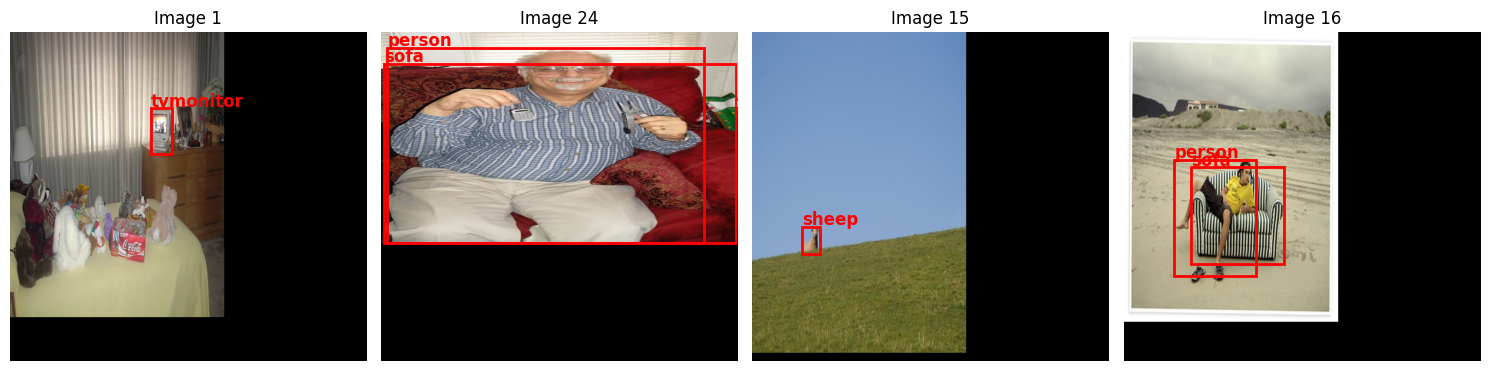

In [ ]:
display_random_batch_images(img, gt_labels, gt_boxes, num_images=4)